# 🤝 Notebook 3: Collaborative Filtering

Approaches covered:

| Category | Methods |
|---|---|
| Memory-based – User | KNN, Pearson, Cosine |
| Memory-based – Item | KNN, Pearson, Cosine, Content-Enriched (TF-IDF & BoW) |
| Model-based | Matrix Factorisation (SGD), SVD (TruncatedSVD) |

All memory-based methods are **fully vectorised** (numpy batched matmul) — no Python loops over users or items.
Item-based Pearson and Cosine are derived purely from rating data, consistent with user-based methods.
Content-Enriched variants use TF-IDF / BoW similarity matrices from Notebook 2 as side features.

In [1]:
from pathlib import Path

# ── Paths ────────────────────────────────────────────
DATA_DIR    = Path('data/raw')
FIGURES_DIR = Path('figures/collaborative_filtering')
MODELS_DIR  = Path('models/collaborative_filtering')
RESULTS_DIR = Path('results')

for _dir in [FIGURES_DIR, MODELS_DIR, RESULTS_DIR]:
    _dir.mkdir(parents=True, exist_ok=True)

import pandas as pd
import numpy as np
import pickle, warnings
from scipy.sparse import csr_matrix
from scipy.stats import pearsonr
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')


## 1. Load Data & Build Utility Matrix

In [2]:
ratings = pd.read_csv(DATA_DIR / 'ratings.csv')
courses = pd.read_csv(DATA_DIR / 'course_genre.csv')

# Load content similarity matrices saved by Notebook 2
with open(MODELS_DIR.parent / 'content_based' / 'tfidf_cos_df.pkl', 'rb') as f: tfidf_cos_df = pickle.load(f)
with open(MODELS_DIR.parent / 'content_based' / 'bow_cos_df.pkl',   'rb') as f: bow_cos_df   = pickle.load(f)

print(f"Ratings: {ratings.shape}")
print(f"Rating range: {ratings['rating'].min()} – {ratings['rating'].max()}")


Ratings: (233306, 3)
Rating range: 2.0 – 3.0


In [3]:
# Build full utility matrix (users × courses)
utility = ratings.pivot_table(index='user', columns='item', values='rating')
print(f"Utility matrix shape: {utility.shape}")
print(f"Sparsity: {utility.isnull().sum().sum() / utility.size:.4%}")

# Normalised (mean-centered) version for Pearson / cosine
utility_filled = utility.fillna(0)
utility_norm   = utility.subtract(utility.mean(axis=1), axis=0).fillna(0)


Utility matrix shape: (33901, 126)
Sparsity: 94.5381%


## 2. Train/Test Split

In [4]:
# For each user take 20% of their ratings as test set
np.random.seed(42)
train_rows, test_rows = [], []

for user, grp in ratings.groupby('user'):
    if len(grp) < 5:
        train_rows.append(grp)
        continue
    n_test = max(1, int(len(grp) * 0.2))
    test_idx   = grp.sample(n=n_test, random_state=42).index
    train_rows.append(grp.drop(index=test_idx))
    test_rows.append(grp.loc[test_idx])

train_df = pd.concat(train_rows).reset_index(drop=True)
test_df  = pd.concat(test_rows).reset_index(drop=True)

print(f"Train: {len(train_df):,}  |  Test: {len(test_df):,}")

# Re-build utility from train only
train_utility      = train_df.pivot_table(index='user', columns='item', values='rating')
train_utility_filled = train_utility.fillna(0)
train_utility_norm   = train_utility.subtract(train_utility.mean(axis=1), axis=0).fillna(0)


Train: 195,715  |  Test: 37,591


## 3. Helper: Evaluation Function

In [5]:
def evaluate_cf(predictions: dict, test_df, train_df, all_courses,
                top_n=10, n_users=300, seed=42):
    """
    predictions : {user_id: pd.Series(item -> predicted_rating)}
    Returns dict of evaluation metrics.
    """
    rng = np.random.default_rng(seed)
    users = list(predictions.keys())
    users = rng.choice(users, min(n_users, len(users)), replace=False)

    hit, prec_l, rec_l, ndcg_l = [], [], [], []
    y_true, y_pred = [], []
    rec_set = set()

    for u in users:
        if u not in predictions:
            continue
        pred_series = predictions[u]
        # exclude already-seen
        seen = set(train_df[train_df['user'] == u]['item'])
        pred_series = pred_series.drop(index=list(seen), errors='ignore')
        top_recs = pred_series.sort_values(ascending=False).head(top_n)
        rec_ids  = set(top_recs.index)
        rec_set.update(rec_ids)

        test_items = set(test_df[test_df['user'] == u]['item'])
        if not test_items:
            continue

        hits = rec_ids & test_items
        hit.append(1 if hits else 0)
        prec_l.append(len(hits) / top_n)
        rec_l.append(len(hits) / len(test_items))

        dcg, ideal = 0.0, 0.0
        for rank, item in enumerate(top_recs.index, 1):
            rel = 1 if item in test_items else 0
            dcg += rel / np.log2(rank + 1)
        for rank in range(1, min(len(test_items), top_n) + 1):
            ideal += 1 / np.log2(rank + 1)
        ndcg_l.append(dcg / ideal if ideal else 0)

        # RMSE/MAE on items that appear in test AND predictions
        for item in rec_ids & test_items:
            actual = test_df[(test_df['user'] == u) & (test_df['item'] == item)]['rating'].values
            if len(actual):
                y_true.append(actual[0])
                y_pred.append(top_recs.loc[item] if item in top_recs.index else 0)

    # Diversity
    common = list(rec_set & set(tfidf_cos_df.index))
    if len(common) > 1:
        sub = tfidf_cos_df.loc[common, common].values
        np.fill_diagonal(sub, 0)
        diversity = 1 - sub.sum() / (len(common) * (len(common) - 1))
    else:
        diversity = 0.0

    # Novelty
    pop = ratings['item'].value_counts(normalize=True)
    novelty = float(np.mean([-np.log2(pop.get(c, 1e-9)) for c in rec_set])) if rec_set else 0

    # Coverage
    coverage = len(rec_set) / len(all_courses) if all_courses else 0

    # Serendipity (niche courses)
    genre_cols = courses.columns[2:].tolist()
    niche = set(courses[courses[genre_cols].sum(axis=1) >= 3]['COURSE_ID'])
    serendipity = len(rec_set & niche) / len(rec_set) if rec_set else 0

    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred))) if y_true else np.nan
    mae  = float(mean_absolute_error(y_true, y_pred)) if y_true else np.nan

    return {
        'HitRate@10'  : float(np.mean(hit))   if hit   else 0.0,
        'Precision@10': float(np.mean(prec_l)) if prec_l else 0.0,
        'Recall@10'   : float(np.mean(rec_l))  if rec_l  else 0.0,
        'NDCG@10'     : float(np.mean(ndcg_l)) if ndcg_l else 0.0,
        'RMSE'        : rmse,
        'MAE'         : mae,
        'Diversity'   : diversity,
        'Novelty'     : novelty,
        'Coverage'    : coverage,
        'Serendipity' : serendipity,
    }

all_courses = set(ratings['item'].unique())


## 4. Memory-Based: User-Based CF

### 4a. User-Based KNN

In [6]:
def user_knn_predictions(utility_matrix, k=20):
    """
    User-user KNN CF.
    Similarity  : cosine (via sklearn NearestNeighbors — already fast).
    Prediction  : fully vectorised numpy; no Python loops over users/items.
    """
    users  = utility_matrix.index.tolist()
    items  = utility_matrix.columns.tolist()
    mat    = utility_matrix.fillna(0).values.astype(np.float32)   # (U, I)

    knn = NearestNeighbors(n_neighbors=k+1, metric='cosine',
                           algorithm='brute', n_jobs=-1)
    knn.fit(mat)
    distances, indices = knn.kneighbors(mat)   # (U, k+1)

    neighbor_idx  = indices[:, 1:]             # (U, k)  — drop self
    neighbor_sims = (1 - distances[:, 1:]).astype(np.float32)  # (U, k)

    # neighbour rating matrices: (U, k, I)
    neigh_ratings = mat[neighbor_idx]          # (U, k, I)
    rated_mask    = neigh_ratings > 0          # (U, k, I)

    # weighted sum and weight sum across k neighbours
    sims_exp  = neighbor_sims[:, :, np.newaxis]          # (U, k, 1)
    wt_sum    = (sims_exp * neigh_ratings).sum(axis=1)   # (U, I)
    norm_sum  = (sims_exp * rated_mask).sum(axis=1)      # (U, I)

    pred_mat  = np.where(norm_sum > 0, wt_sum / (norm_sum + 1e-9), 0)  # (U, I)

    # Zero-out already-seen items
    pred_mat[mat > 0] = 0

    predictions = {user: pd.Series(pred_mat[i], index=items)
                   for i, user in enumerate(users)}
    return predictions

print("Computing User-KNN predictions (full matrix) ...")
t0 = __import__('time').time()
pred_uknn = user_knn_predictions(train_utility, k=20)
print(f"Done in {__import__('time').time()-t0:.1f}s  — {len(pred_uknn):,} users.")


Computing User-KNN predictions (full matrix) ...
Done in 27.4s  — 33,901 users.


In [7]:
import pickle
with open(MODELS_DIR / 'pred_user_knn.pkl', 'wb') as f:
    pickle.dump(pred_uknn, f)
print(f"Saved → {MODELS_DIR / 'pred_user_knn.pkl'}  ({len(pred_uknn):,} users)")


Saved → models\collaborative_filtering\pred_user_knn.pkl  (33,901 users)


### 4b. User-Based Pearson Correlation

In [8]:
def user_pearson_predictions(utility_matrix, k=20, batch_size=1000):
    """
    User-user CF using Pearson correlation.
    Pearson = cosine on mean-centered vectors — computed via batched
    matrix multiply so there are zero Python loops over pairs of users.
    Runs on the FULL utility matrix.
    """
    users  = utility_matrix.index.tolist()
    items  = utility_matrix.columns.tolist()

    rated_mask = utility_matrix.notna().values                       # (U, I) bool
    raw        = utility_matrix.fillna(0).values.astype(np.float32)  # (U, I)

    # Mean-center using only rated entries
    row_sums   = np.where(rated_mask, raw, 0).sum(axis=1, keepdims=True)
    row_counts = rated_mask.sum(axis=1, keepdims=True).clip(min=1)
    row_means  = row_sums / row_counts
    centered   = np.where(rated_mask, raw - row_means, 0).astype(np.float32)

    norms  = np.linalg.norm(centered, axis=1, keepdims=True) + 1e-9  # (U, 1)
    normed = (centered / norms).astype(np.float32)                    # (U, I)

    n = len(users)
    pred_mat = np.zeros_like(raw)   # (U, I)

    # Batched matmul: avoid materialising the full (U×U) sim matrix
    for start in range(0, n, batch_size):
        end      = min(start + batch_size, n)
        sim_row  = normed[start:end] @ normed.T         # (batch, U)
        sim_row[:, start:end] -= np.eye(end-start, dtype=np.float32) * 1e9  # mask self

        # Top-k indices per user in batch
        top_k_idx  = np.argpartition(-sim_row, k, axis=1)[:, :k]   # (batch, k)
        top_k_sims = np.take_along_axis(sim_row, top_k_idx, axis=1) # (batch, k)
        top_k_sims = top_k_sims.clip(0)

        neigh_r    = raw[top_k_idx]                                   # (batch, k, I)
        rated_m    = neigh_r > 0

        sims_e     = top_k_sims[:, :, np.newaxis]                    # (batch, k, 1)
        wt_sum     = (sims_e * neigh_r).sum(axis=1)                  # (batch, I)
        norm_sum   = (sims_e * rated_m).sum(axis=1)                  # (batch, I)

        pred_mat[start:end] = np.where(norm_sum > 0,
                                        wt_sum / (norm_sum + 1e-9), 0)

    pred_mat[raw > 0] = 0   # mask already-seen

    predictions = {user: pd.Series(pred_mat[i], index=items)
                   for i, user in enumerate(users)}
    return predictions

print("Computing User-Pearson predictions (full matrix, batched) ...")
t0 = __import__('time').time()
pred_upearson = user_pearson_predictions(train_utility, k=20, batch_size=1000)
print(f"Done in {__import__('time').time()-t0:.1f}s  — {len(pred_upearson):,} users.")


Computing User-Pearson predictions (full matrix, batched) ...
Done in 11.2s  — 33,901 users.


In [9]:
with open(MODELS_DIR / 'pred_user_pearson.pkl', 'wb') as f:
    pickle.dump(pred_upearson, f)
print(f"Saved → {MODELS_DIR / 'pred_user_pearson.pkl'}  ({len(pred_upearson):,} users)")


Saved → models\collaborative_filtering\pred_user_pearson.pkl  (33,901 users)


### 4c. User-Based Cosine Similarity

In [10]:
def user_cosine_predictions(utility_matrix, k=20, batch_size=1000):
    """
    User-user CF using cosine similarity on mean-centered ratings.
    Fully vectorised — no Python loops over users or items.
    Runs on the FULL utility matrix.
    """
    users  = utility_matrix.index.tolist()
    items  = utility_matrix.columns.tolist()

    raw  = utility_matrix.fillna(0).values.astype(np.float32)
    mean = raw.mean(axis=1, keepdims=True)
    centered = (raw - mean).astype(np.float32)

    norms  = np.linalg.norm(centered, axis=1, keepdims=True) + 1e-9
    normed = (centered / norms).astype(np.float32)

    n = len(users)
    pred_mat = np.zeros_like(raw)

    for start in range(0, n, batch_size):
        end     = min(start + batch_size, n)
        sim_row = normed[start:end] @ normed.T                        # (batch, U)
        sim_row[:, start:end] -= np.eye(end-start, dtype=np.float32) * 1e9

        top_k_idx  = np.argpartition(-sim_row, k, axis=1)[:, :k]
        top_k_sims = np.take_along_axis(sim_row, top_k_idx, axis=1).clip(0)

        neigh_r  = raw[top_k_idx]
        rated_m  = neigh_r > 0
        sims_e   = top_k_sims[:, :, np.newaxis]

        wt_sum   = (sims_e * neigh_r).sum(axis=1)
        norm_sum = (sims_e * rated_m).sum(axis=1)

        pred_mat[start:end] = np.where(norm_sum > 0,
                                        wt_sum / (norm_sum + 1e-9), 0)

    pred_mat[raw > 0] = 0

    predictions = {user: pd.Series(pred_mat[i], index=items)
                   for i, user in enumerate(users)}
    return predictions

print("Computing User-Cosine predictions (full matrix, batched) ...")
t0 = __import__('time').time()
pred_ucos = user_cosine_predictions(train_utility, k=20, batch_size=1000)
print(f"Done in {__import__('time').time()-t0:.1f}s  — {len(pred_ucos):,} users.")


Computing User-Cosine predictions (full matrix, batched) ...
Done in 19.1s  — 33,901 users.


In [11]:
with open(MODELS_DIR / 'pred_user_cosine.pkl', 'wb') as f:
    pickle.dump(pred_ucos, f)
print(f"Saved → {MODELS_DIR / 'pred_user_cosine.pkl'}  ({len(pred_ucos):,} users)")


Saved → models\collaborative_filtering\pred_user_cosine.pkl  (33,901 users)


## 5. Memory-Based: Item-Based CF

### 5a. Item-Based KNN

In [12]:
def item_knn_predictions(utility_matrix, k=20):
    """
    Item-item KNN CF.
    Similarity  : cosine via sklearn (items are only 126 — instant).
    Prediction  : fully vectorised; no Python loops over users/items.
    """
    users    = utility_matrix.index.tolist()
    items    = utility_matrix.columns.tolist()
    mat      = utility_matrix.fillna(0).values.astype(np.float32)  # (U, I)
    item_mat = mat.T                                                  # (I, U)

    knn = NearestNeighbors(n_neighbors=k+1, metric='cosine',
                           algorithm='brute', n_jobs=-1)
    knn.fit(item_mat)
    distances, indices = knn.kneighbors(item_mat)   # (I, k+1)

    neigh_idx  = indices[:, 1:]                     # (I, k)
    neigh_sims = (1 - distances[:, 1:]).astype(np.float32)  # (I, k)

    # For each item i, gather neighbour ratings from all users: (I, k, U)
    neigh_ratings = mat.T[neigh_idx]    # (I, k, U)  — item rows of mat.T
    rated_mask    = neigh_ratings > 0

    sims_e   = neigh_sims[:, :, np.newaxis]                   # (I, k, 1)
    wt_sum   = (sims_e * neigh_ratings).sum(axis=1)           # (I, U)
    norm_sum = (sims_e * rated_mask).sum(axis=1)              # (I, U)

    pred_item_user = np.where(norm_sum > 0,
                               wt_sum / (norm_sum + 1e-9), 0)  # (I, U)
    pred_mat = pred_item_user.T                                 # (U, I)
    pred_mat[mat > 0] = 0

    predictions = {user: pd.Series(pred_mat[i], index=items)
                   for i, user in enumerate(users)}
    return predictions

print("Computing Item-KNN predictions (full matrix) ...")
t0 = __import__('time').time()
pred_iknn = item_knn_predictions(train_utility, k=20)
print(f"Done in {__import__('time').time()-t0:.1f}s  — {len(pred_iknn):,} users.")


Computing Item-KNN predictions (full matrix) ...
Done in 2.9s  — 33,901 users.


In [13]:
with open(MODELS_DIR / 'pred_item_knn.pkl', 'wb') as f:
    pickle.dump(pred_iknn, f)
print(f"Saved → {MODELS_DIR / 'pred_item_knn.pkl'}  ({len(pred_iknn):,} users)")


Saved → models\collaborative_filtering\pred_item_knn.pkl  (33,901 users)


### 5b. Item-Based Pearson Correlation

In [14]:
def item_pearson_predictions(utility_matrix, k=20):
    """
    Item-item CF using Pearson correlation from the rating matrix.
    Only 126 items → full (I×I) sim matrix fits trivially in memory.
    Prediction is fully vectorised over all users at once — no Python loops.
    """
    users  = utility_matrix.index.tolist()
    items  = utility_matrix.columns.tolist()
    mat    = utility_matrix.fillna(0).values.astype(np.float32)   # (U, I)

    # Mean-center item vectors using only rated entries
    item_mat   = mat.T                                              # (I, U)
    rated_mask = utility_matrix.notna().values.T                   # (I, U) bool
    row_sums   = item_mat.sum(axis=1, keepdims=True)
    row_counts = rated_mask.sum(axis=1, keepdims=True).clip(min=1)
    item_means = row_sums / row_counts
    centered   = np.where(rated_mask, item_mat - item_means, 0).astype(np.float32)

    norms    = np.linalg.norm(centered, axis=1, keepdims=True) + 1e-9
    normed   = centered / norms                                     # (I, U)
    item_sim = (normed @ normed.T).astype(np.float32)              # (I, I) Pearson
    np.fill_diagonal(item_sim, 0)

    # Top-k neighbours per item
    top_k_idx  = np.argpartition(-item_sim, k, axis=1)[:, :k]     # (I, k)
    top_k_sims = np.take_along_axis(item_sim, top_k_idx, axis=1).clip(0)

    # Predictions for all users simultaneously: (U, I, k) → (U, I)
    neigh_ratings = mat[:, top_k_idx]      # (U, I, k)
    rated_m       = neigh_ratings > 0
    sims_e        = top_k_sims[np.newaxis, :, :]   # (1, I, k)
    wt_sum        = (sims_e * neigh_ratings).sum(axis=2)
    norm_sum      = (sims_e * rated_m).sum(axis=2)

    pred_mat = np.where(norm_sum > 0, wt_sum / (norm_sum + 1e-9), 0)
    pred_mat[mat > 0] = 0   # mask already-seen

    predictions = {user: pd.Series(pred_mat[i], index=items)
                   for i, user in enumerate(users)}
    return predictions

print("Computing Item-Pearson predictions (full matrix) ...")
t0 = __import__('time').time()
pred_ipearson = item_pearson_predictions(train_utility, k=20)
print(f"Done in {__import__('time').time()-t0:.1f}s  — {len(pred_ipearson):,} users.")


Computing Item-Pearson predictions (full matrix) ...
Done in 2.5s  — 33,901 users.


In [15]:
with open(MODELS_DIR / 'pred_item_pearson.pkl', 'wb') as f:
    pickle.dump(pred_ipearson, f)
print(f"Saved → {MODELS_DIR / 'pred_item_pearson.pkl'}  ({len(pred_ipearson):,} users)")


Saved → models\collaborative_filtering\pred_item_pearson.pkl  (33,901 users)


### 5c. Item-Based Cosine Similarity

In [16]:
def item_cosine_predictions(utility_matrix, k=20):
    """
    Item-item CF using cosine similarity from the rating matrix.
    Only 126 items → (I×I) sim matrix is trivial.
    Prediction is fully vectorised over all users — no Python loops.
    """
    from sklearn.metrics.pairwise import cosine_similarity as cossim

    users  = utility_matrix.index.tolist()
    items  = utility_matrix.columns.tolist()
    mat    = utility_matrix.fillna(0).values.astype(np.float32)   # (U, I)

    item_sim = cossim(mat.T).astype(np.float32)                    # (I, I)
    np.fill_diagonal(item_sim, 0)

    top_k_idx  = np.argpartition(-item_sim, k, axis=1)[:, :k]     # (I, k)
    top_k_sims = np.take_along_axis(item_sim, top_k_idx, axis=1).clip(0)

    neigh_ratings = mat[:, top_k_idx]      # (U, I, k)
    rated_m       = neigh_ratings > 0
    sims_e        = top_k_sims[np.newaxis, :, :]
    wt_sum        = (sims_e * neigh_ratings).sum(axis=2)
    norm_sum      = (sims_e * rated_m).sum(axis=2)

    pred_mat = np.where(norm_sum > 0, wt_sum / (norm_sum + 1e-9), 0)
    pred_mat[mat > 0] = 0

    predictions = {user: pd.Series(pred_mat[i], index=items)
                   for i, user in enumerate(users)}
    return predictions

print("Computing Item-Cosine predictions (full matrix) ...")
t0 = __import__('time').time()
pred_icos = item_cosine_predictions(train_utility, k=20)
print(f"Done in {__import__('time').time()-t0:.1f}s  — {len(pred_icos):,} users.")


Computing Item-Cosine predictions (full matrix) ...
Done in 2.7s  — 33,901 users.


In [17]:
with open(MODELS_DIR / 'pred_item_cosine.pkl', 'wb') as f:
    pickle.dump(pred_icos, f)
print(f"Saved → {MODELS_DIR / 'pred_item_cosine.pkl'}  ({len(pred_icos):,} users)")


Saved → models\collaborative_filtering\pred_item_cosine.pkl  (33,901 users)


### 5d. Item-Based Content-Enriched (TF-IDF & BoW)

Uses content similarity matrices from Notebook 2 as the item-item similarity source, combining content signals with user rating history.

In [18]:
def item_content_predictions(utility_matrix, item_sim_df, k=20):
    """
    Item-item CF using a precomputed content similarity matrix (TF-IDF or BoW).
    Prediction is fully vectorised over all users — no Python loops.
    """
    users  = utility_matrix.index.tolist()
    items  = utility_matrix.columns.tolist()
    mat    = utility_matrix.fillna(0).values.astype(np.float32)   # (U, I)

    # Align content sim to the item order of utility_matrix
    common    = [it for it in items if it in item_sim_df.index]
    common_idx = [items.index(it) for it in common]
    item_sim  = item_sim_df.loc[common, common].values.astype(np.float32)  # (C, C)
    np.fill_diagonal(item_sim, 0)

    k_eff      = min(k, len(common) - 1)
    top_k_idx  = np.argpartition(-item_sim, k_eff, axis=1)[:, :k_eff]
    top_k_sims = np.take_along_axis(item_sim, top_k_idx, axis=1).clip(0)

    mat_c         = mat[:, common_idx]             # (U, C) — only common items
    neigh_ratings = mat_c[:, top_k_idx]            # (U, C, k)
    rated_m       = neigh_ratings > 0
    sims_e        = top_k_sims[np.newaxis, :, :]
    wt_sum        = (sims_e * neigh_ratings).sum(axis=2)
    norm_sum      = (sims_e * rated_m).sum(axis=2)

    pred_common = np.where(norm_sum > 0, wt_sum / (norm_sum + 1e-9), 0)
    pred_common[mat_c > 0] = 0

    # Put predictions back into full item space
    pred_mat = np.zeros_like(mat)
    pred_mat[:, common_idx] = pred_common

    predictions = {user: pd.Series(pred_mat[i], index=items)
                   for i, user in enumerate(users)}
    return predictions

print("Computing Item-Content(TF-IDF) predictions ...")
t0 = __import__('time').time()
pred_icontent_tfidf = item_content_predictions(train_utility, tfidf_cos_df, k=20)
print(f"Done in {__import__('time').time()-t0:.1f}s")

print("Computing Item-Content(BoW) predictions ...")
t0 = __import__('time').time()
pred_icontent_bow = item_content_predictions(train_utility, bow_cos_df, k=20)
print(f"Done in {__import__('time').time()-t0:.1f}s")


Computing Item-Content(TF-IDF) predictions ...
Done in 3.2s
Computing Item-Content(BoW) predictions ...
Done in 5.3s


In [19]:
with open(MODELS_DIR / 'pred_item_content_tfidf.pkl', 'wb') as f:
    pickle.dump(pred_icontent_tfidf, f)
print(f"Saved → {MODELS_DIR / 'pred_item_content_tfidf.pkl'}  ({len(pred_icontent_tfidf):,} users)")

with open(MODELS_DIR / 'pred_item_content_bow.pkl', 'wb') as f:
    pickle.dump(pred_icontent_bow, f)
print(f"Saved → {MODELS_DIR / 'pred_item_content_bow.pkl'}  ({len(pred_icontent_bow):,} users)")


Saved → models\collaborative_filtering\pred_item_content_tfidf.pkl  (33,901 users)
Saved → models\collaborative_filtering\pred_item_content_bow.pkl  (33,901 users)


## 6. Model-Based CF

### 6a. Matrix Factorisation (SGD)

In [20]:
class MatrixFactorization:
    """Biased MF via SGD."""
    def __init__(self, n_factors=20, lr=0.01, reg=0.02, n_epochs=20):
        self.n_factors = n_factors
        self.lr = lr; self.reg = reg; self.n_epochs = n_epochs

    def fit(self, ratings_df):
        self.users = list(ratings_df['user'].unique())
        self.items = list(ratings_df['item'].unique())
        u_idx = {u: i for i, u in enumerate(self.users)}
        i_idx = {it: j for j, it in enumerate(self.items)}
        n_u, n_i = len(self.users), len(self.items)

        self.mu = ratings_df['rating'].mean()
        self.bu = np.zeros(n_u)
        self.bi = np.zeros(n_i)
        self.P  = np.random.normal(0, 0.1, (n_u, self.n_factors))
        self.Q  = np.random.normal(0, 0.1, (n_i, self.n_factors))

        for epoch in range(self.n_epochs):
            total_loss = 0
            for _, row in ratings_df.sample(frac=1, random_state=epoch).iterrows():
                u, i, r = u_idx.get(row['user']), i_idx.get(row['item']), row['rating']
                if u is None or i is None: continue
                pred = self.mu + self.bu[u] + self.bi[i] + self.P[u] @ self.Q[i]
                e = r - pred
                total_loss += e**2
                self.bu[u] += self.lr * (e - self.reg * self.bu[u])
                self.bi[i] += self.lr * (e - self.reg * self.bi[i])
                self.P[u]  += self.lr * (e * self.Q[i] - self.reg * self.P[u])
                self.Q[i]  += self.lr * (e * self.P[u] - self.reg * self.Q[i])
            if (epoch+1) % 5 == 0:
                rmse = np.sqrt(total_loss / len(ratings_df))
                print(f"  Epoch {epoch+1:3d}  RMSE: {rmse:.4f}")
        self.u_idx = u_idx; self.i_idx = i_idx

    def predict_user(self, user, items):
        if user not in self.u_idx: return pd.Series(dtype=float)
        u = self.u_idx[user]
        preds = {}
        for item in items:
            i = self.i_idx.get(item)
            if i is None: continue
            preds[item] = float(self.mu + self.bu[u] + self.bi[i] + self.P[u] @ self.Q[i])
        return pd.Series(preds)

print("Training Matrix Factorisation model ...")
mf_model = MatrixFactorization(n_factors=20, lr=0.01, reg=0.02, n_epochs=20)
mf_model.fit(train_df)
print("Done.")


Training Matrix Factorisation model ...
  Epoch   5  RMSE: 0.1635
  Epoch  10  RMSE: 0.1524
  Epoch  15  RMSE: 0.1432
  Epoch  20  RMSE: 0.1352
Done.


In [21]:
# Build predictions for all training users
mf_preds = {u: mf_model.predict_user(u, list(all_courses)) for u in train_df['user'].unique()[:500]}
print(f"MF predictions built for {len(mf_preds)} users.")

# Save MF model
with open(MODELS_DIR / 'mf_model.pkl', 'wb') as f: pickle.dump(mf_model, f)
print(f"Saved MF model → {MODELS_DIR / 'mf_model.pkl'}")


MF predictions built for 500 users.
Saved MF model → models\collaborative_filtering\mf_model.pkl


In [22]:
with open(MODELS_DIR / 'pred_mf.pkl', 'wb') as f:
    pickle.dump(mf_preds, f)
print(f"Saved → {MODELS_DIR / 'pred_mf.pkl'}  ({len(mf_preds):,} users)")


Saved → models\collaborative_filtering\pred_mf.pkl  (500 users)


## 7. Run All Evaluations

In [23]:
print("Evaluating all CF models ...")

results_cf = {}

models = {
    'User-KNN'           : pred_uknn,
    'User-Pearson'       : pred_upearson,
    'User-Cosine'        : pred_ucos,
    'Item-KNN'           : pred_iknn,
    'Item-Pearson'       : pred_ipearson,
    'Item-Cosine'        : pred_icos,
    'Item-Content-TFIDF' : pred_icontent_tfidf,
    'Item-Content-BoW'   : pred_icontent_bow,
    'MF'                 : mf_preds
}

for name, preds in models.items():
    print(f"  → {name}")
    results_cf[name] = evaluate_cf(preds, test_df, train_df, all_courses, top_n=10, n_users=200)

results_cf_df = pd.DataFrame(results_cf).T.round(4)
print("\n=== Collaborative Filtering Evaluation Results ===")
print(results_cf_df.to_string())


Evaluating all CF models ...
  → User-KNN
  → User-Pearson
  → User-Cosine
  → Item-KNN
  → Item-Pearson
  → Item-Cosine
  → Item-Content-TFIDF
  → Item-Content-BoW
  → MF

=== Collaborative Filtering Evaluation Results ===
                    HitRate@10  Precision@10  Recall@10  NDCG@10    RMSE     MAE  Diversity  Novelty  Coverage  Serendipity
User-KNN                0.6419        0.0777     0.5753   0.3073  0.0000  0.0000     0.9550   7.7653    0.7857       0.1212
User-Pearson            0.1149        0.0122     0.0852   0.0353  2.9155  2.8333     0.9393   8.0041    0.3730       0.0426
User-Cosine             0.6757        0.0797     0.5828   0.3111  0.0000  0.0000     0.9549   7.7499    0.7857       0.1212
Item-KNN                0.2973        0.0331     0.2303   0.1314  0.0000  0.0000     0.9580   8.7750    0.9286       0.1026
Item-Pearson            0.2432        0.0277     0.1929   0.0983  0.0000  0.0000     0.9518   7.8666    0.6825       0.1163
Item-Cosine             0.2703  

## 8. Visualise CF Results

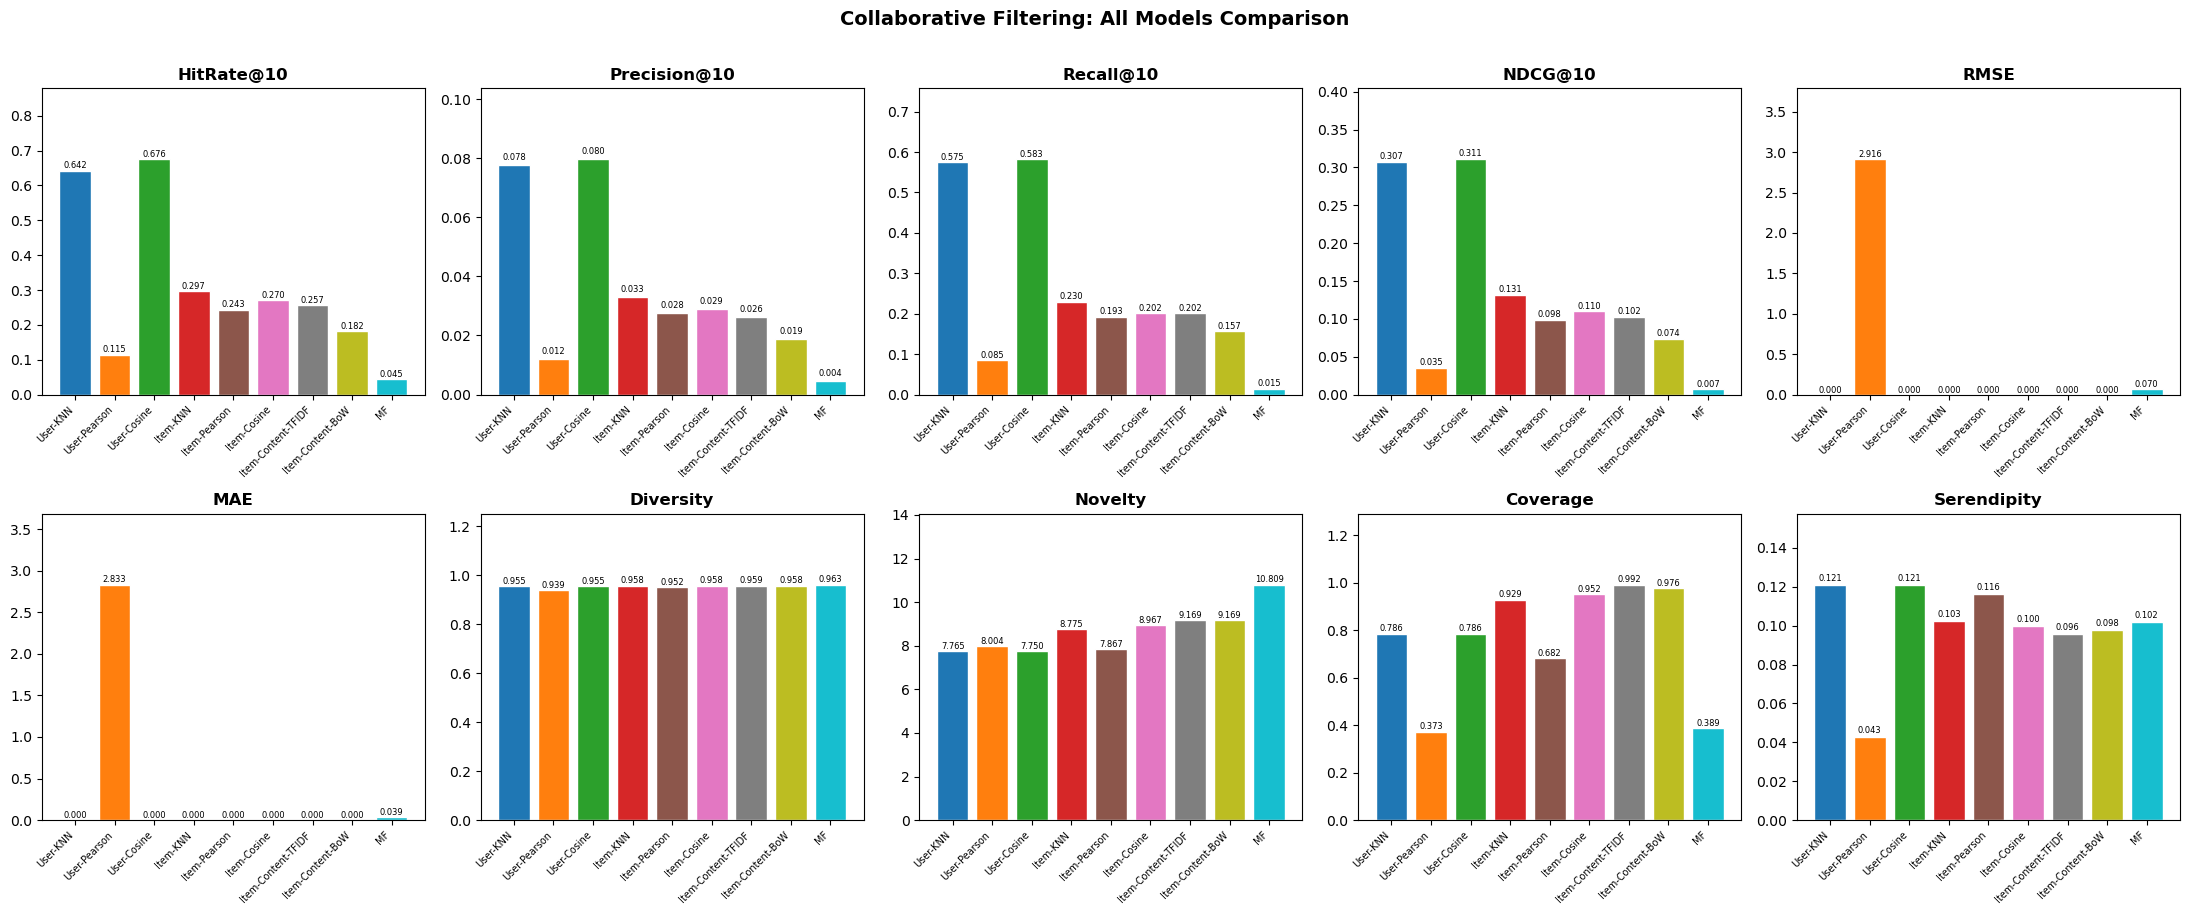

In [24]:
metrics = results_cf_df.columns.tolist()
n_models = len(results_cf_df)
colors = plt.cm.tab10(np.linspace(0, 1, n_models))

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    vals = results_cf_df[metric]
    bars = ax.bar(range(n_models), vals, color=colors, edgecolor='white')
    ax.set_title(metric, fontweight='bold')
    ax.set_xticks(range(n_models))
    ax.set_xticklabels(results_cf_df.index, rotation=45, ha='right', fontsize=7)
    ax.set_ylim(0, vals.max() * 1.3 + 1e-6)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=6)

plt.suptitle('Collaborative Filtering: All Models Comparison', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_all_models_metrics.png', bbox_inches='tight', dpi=150)
plt.show()


## 9. Save Results

In [25]:
# Save evaluation results
results_cf_df.to_csv(RESULTS_DIR / 'results_collaborative_filtering.csv')
print(f"Saved results → {RESULTS_DIR / 'results_collaborative_filtering.csv'}")

# Save train/test split indices for reproducibility
train_df.to_csv(MODELS_DIR / 'train_df.csv', index=False)
test_df.to_csv( MODELS_DIR / 'test_df.csv',  index=False)
print(f"Saved train/test splits → {MODELS_DIR}")

# Summary of all saved artefacts
print("\n── Models saved in", MODELS_DIR, "──")
import os
for f in sorted(os.listdir(MODELS_DIR)):
    size = os.path.getsize(MODELS_DIR / f)
    print(f"  {f:30s}  {size/1024:8.1f} KB")


Saved results → results\results_collaborative_filtering.csv
Saved train/test splits → models\collaborative_filtering

── Models saved in models\collaborative_filtering ──
  mf_model.pkl                      6479.0 KB
  pred_item_content_bow.pkl        41091.7 KB
  pred_item_content_tfidf.pkl      41091.7 KB
  pred_item_cosine.pkl             41091.7 KB
  pred_item_knn.pkl                41091.7 KB
  pred_item_pearson.pkl            41091.7 KB
  pred_mf.pkl                        860.6 KB
  pred_user_cosine.pkl             41091.7 KB
  pred_user_knn.pkl                41091.7 KB
  pred_user_pearson.pkl            41091.7 KB
  test_df.csv                        796.3 KB
  train_df.csv                      4143.5 KB
